# 01 — Conditioning and capacity

Two halves that share one machinery.

**Conditioning** (`network_conditioning.py`) turns an arbitrary `.inp` into a
simulation-ready model plus a *recipe* recording every change and why. The source file
is never edited. Storage policy is tried on a ladder of increasing intrusiveness
(`as_is` → `synth_controls` → `freeze_tanks`) and the first policy that produces a
usable model wins, with every rejected attempt logged.

**Capacity** (`network_capacity.py`) answers how much demand each network can carry, at
constant demand and steady state, by scaling a single multiplier λ. Three things are
kept apart on purpose: defects that fail regardless of demand, whether capacity is even
well defined (monotonicity), and what failure means (DD's pressure cliff vs PDD's
unserved demand).

Two conditioning *profiles* are used, because the two questions need different models:

| profile | patterns | duration | used for |
|---|---|---|---|
| capacity | flattened (constant) | 0 h (steady state) | λ sweeps — no tank drift, λ is the only knob |
| timeseries | kept, length normalised | 24 h | "can this network run at all" |

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd()))
import network_capacity as cap
import network_conditioning as nc

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 200)
warnings.simplefilter("ignore")

NETWORK_DIR = Path("../../data/00_networks")
OUT_DIR = Path("data/08_reporting/capacity")
RECIPE_DIR = Path("data/01_raw/conditioning_recipes")
CONDITIONED_DIR = Path("data/02_intermediate/conditioned")
for d in (OUT_DIR, RECIPE_DIR, CONDITIONED_DIR):
    d.mkdir(parents=True, exist_ok=True)

SUBSET = None            # None = whole corpus
FOCUS = "ky15"
PRESSURE_FLOOR_M = 15.0  # ABNT NBR 12218 residential minimum

files = sorted(NETWORK_DIR.glob("*.inp"))
if SUBSET:
    files = [f for f in files if f.stem in SUBSET]
print(f"{len(files)} networks; wntr {nc.wntr.__version__}")

26 networks; wntr 1.3.2


In [2]:
# The two profiles. Everything that affects physics is pinned here, from config,
# never inherited from a file default.
CFG_TIMESERIES = nc.ConditioningConfig(
    fold_demand_multiplier=True,      # frees the multiplier as OUR scaling knob
    flatten_patterns=False,
    normalize_pattern_length=24,      # the KY files ship 23-step diurnal patterns
    duration_h=24.0,
    timestep_s=3600,
    demand_model="DD",
)

CFG_CAPACITY = cap.CapacityConfig(
    pressure_floor_m=PRESSURE_FLOOR_M,
    lambda_grid=(0.05, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0, 5.0, 8.0, 12.0, 20.0),
    tank_levels=("initial", "min"),   # storage-dependence of the answer
    modes=("DD", "PDD"),              # cliff vs graded failure
)
CFG_CAPACITY

CapacityConfig(pressure_floor_m=15.0, lambda_grid=(0.05, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0, 5.0, 8.0, 12.0, 20.0), bisect_tol=0.02, bisect_max_iter=16, monotonic_tol_m=0.5, tank_levels=('initial', 'min'), modes=('DD', 'PDD'), sanity_head_m=1000.0, freeze_tanks=False)

## 1. Conditioning

### 1a. One network, and its recipe

The recipe is the deliverable: hand-editable, diffable, replayable. Note that steps which
*did nothing* are logged too — "no tanks, storage policy irrelevant" is information.

In [3]:
wn_one, recipe_one, attempts_one = nc.auto_condition(
    NETWORK_DIR / f"{FOCUS}.inp", CFG_TIMESERIES, pressure_floor_m=PRESSURE_FLOOR_M)
display(recipe_one.to_frame()[["order", "step", "changed", "detail"]])
display(attempts_one[["policy", "usable", "pressure_min_m", "pressure_max_m",
                      "frac_negative", "sane", "reason"]])
print(recipe_one.save(RECIPE_DIR / f"{FOCUS}.yml"))

,order,step,changed,detail
0,0,fold_demand_multiplier,False,multiplier already 1.0
1,1,synthesize_demand,False,file already carries 64.72 L/s
2,2,normalize_pattern_lengths,True,ENRG1:23->24 (padded cyclically)
3,3,storage_policy,False,as_is: tanks and controls untouched
4,4,set_time_and_solver_options,True,"{'duration_h': 0.0, 'hydraulic_timestep_s': 60..."
5,5,auto_condition,True,tier=T3_infeasible via storage_policy=as_is af...


,policy,usable,pressure_min_m,pressure_max_m,frac_negative,sane,reason
0,as_is,False,-160.401978,140.811890,0.031434,True,negative consumer pressure
1,synth_controls,False,-451836.875000,5382.564453,0.108602,False,non-physical overpressure (5383 m)
2,freeze_tanks,False,-164.457138,141.077255,0.033558,True,negative consumer pressure


data\01_raw\conditioning_recipes\ky15.yml


### 1b. The whole corpus, tiered

`T0_as_is` runs untouched · `T1_conditioned` runs after a storage policy · `T2_needs_demand`
carries no demand at all · `T3_infeasible` fails every policy on the ladder.

In [4]:
cond = nc.condition_corpus(files, CFG_TIMESERIES,
                           pressure_floor_m=PRESSURE_FLOOR_M,
                           recipe_dir=RECIPE_DIR, inp_dir=CONDITIONED_DIR)
for name, df in cond.items():
    df.to_csv(OUT_DIR / f"conditioning_{name}.csv", index=False)

cond["tiers"][["network", "tier", "storage_policy", "n_attempts", "n_consumers",
               "n_tanks", "n_controls", "usable", "meets_floor",
               "pressure_min_m", "pressure_max_m", "overpressure"]]

  Balerma        0.3s  T0_as_is         as_is
  C_Town         0.1s  T2_needs_demand  as_is
  D_Town         0.3s  T0_as_is         as_is
  Graeme         0.1s  T0_as_is         as_is
  ky1            1.0s  T1_conditioned   freeze_tanks
  ky10           1.5s  T1_conditioned   freeze_tanks
  ky11           0.7s  T0_as_is         as_is
  ky12           3.0s  T1_conditioned   freeze_tanks
  ky13           0.7s  T0_as_is         as_is
  ky14           5.4s  T1_conditioned   freeze_tanks
  ky15           1.1s  T3_infeasible    as_is
  ky16           0.5s  T0_as_is         as_is
  ky17           3.6s  T0_as_is         as_is
  ky18           0.5s  T0_as_is         as_is
  ky19_v         0.9s  T0_as_is         as_is
  ky2            0.6s  T0_as_is         as_is
  ky3            0.5s  T1_conditioned   freeze_tanks
  ky4            0.5s  T0_as_is         as_is
  ky5            0.5s  T0_as_is         as_is
  ky6            0.4s  T0_as_is         as_is
  ky7            0.4s  T0_as_is         as_is

,network,tier,storage_policy,n_attempts,n_consumers,n_tanks,n_controls,usable,meets_floor,pressure_min_m,pressure_max_m,overpressure
0,Balerma,T0_as_is,as_is,1,442,0,0,True,True,20.001383,68.460991,False
1,C_Town,T2_needs_demand,as_is,1,0,7,20,False,False,NaN,NaN,False
2,D_Town,T0_as_is,as_is,1,348,7,24,True,True,18.243679,102.776062,False
3,Graeme,T0_as_is,as_is,1,112,0,0,True,False,2.138651,10.216875,False
4,ky1,T1_conditioned,freeze_tanks,3,797,0,0,True,True,23.392023,152.462769,False
5,ky10,T1_conditioned,freeze_tanks,3,871,0,0,True,True,29.803730,105.206116,False
6,ky11,T0_as_is,as_is,1,694,28,12,True,True,18.377874,133.013947,False
7,ky12,T1_conditioned,freeze_tanks,3,2246,0,0,True,True,21.382702,105.255844,False
8,ky13,T0_as_is,as_is,1,718,5,6,True,False,2.455258,115.845482,False
9,ky14,T1_conditioned,freeze_tanks,3,331,0,0,True,True,24.331596,114.457848,False


In [7]:
# Why each rejected policy was rejected. Note the two distinct failure modes:
# negative consumer pressure (the network cannot deliver) and non-physical
# overpressure (a POWER pump deadheading -- head = P/(rho*g*Q) diverges as Q->0).
# A floor-only check would have called the overpressure cases healthy.
att = cond["attempts"]
display(att[~att.usable][["network", "policy", "pressure_min_m", "pressure_max_m",
                          "frac_negative", "sane", "reason"]].reset_index(drop=True))
print(cond["tiers"].groupby(["tier", "storage_policy"]).size().to_string())

,network,policy,pressure_min_m,pressure_max_m,frac_negative,sane,reason
0,C_Town,as_is,NaN,NaN,NaN,NaN,no demand in file
1,ky1,as_is,-142.285019,152.462769,0.760000,True,negative consumer pressure
2,ky1,synth_controls,-142.285019,152.462769,0.760000,True,negative consumer pressure
3,ky10,as_is,-118.871429,105.206116,0.001929,True,negative consumer pressure
4,ky10,synth_controls,-117.811409,105.206116,0.001929,True,negative consumer pressure
5,ky12,as_is,-12.671542,105.589653,0.001977,True,negative consumer pressure
6,ky12,synth_controls,-8.460971,110.108528,0.000855,True,negative consumer pressure
7,ky14,as_is,25.002085,6493.548340,0.000000,False,non-physical overpressure (6494 m)
8,ky14,synth_controls,18.721977,83767.851562,0.000000,False,non-physical overpressure (83768 m)
9,ky15,as_is,-160.401978,140.811890,0.031434,True,negative consumer pressure


tier             storage_policy
T0_as_is         as_is             18
T1_conditioned   freeze_tanks       6
T2_needs_demand  as_is              1
T3_infeasible    as_is              1


In [8]:
# Canonical ID map — a mapping layer, not a rename. IDs inside the .inp are left
# alone (rewriting them breaks controls and rules and destroys traceability);
# downstream code speaks canonical_id. Type-qualified because Balerma reuses 324
# IDs across element types, so a bare ID is not a key.
idm = cond["id_map"]
display(idm.groupby(["network", "role"]).size().unstack(fill_value=0))
display(idm[idm.network == FOCUS].head(8))

role,consumer,injection,pipe,pump,reservoir,structural,tank,transit,valve
network,,,,,,,,,
Balerma,442,0,454,0,4,0,0,1,0
C_Town,0,0,429,11,1,15,7,373,4
D_Town,348,0,443,11,1,13,7,38,5
Graeme,112,0,164,0,1,0,0,1,0
NJ1,13306,14,16066,12,0,18,8,1653,0
PA1,294,21,399,0,0,0,2,22,0
ky1,797,0,984,1,3,2,0,57,0
ky10,871,0,1043,13,15,34,0,15,5
ky11,694,0,846,21,1,68,28,40,15


,network,element_type,source_id,canonical_id,role
15922,ky15,junction,I-Pump-1,ky15:J:00001,structural
15923,ky15,junction,I-Pump-10,ky15:J:00002,structural
15924,ky15,junction,I-Pump-11,ky15:J:00003,structural
15925,ky15,junction,I-Pump-12,ky15:J:00004,structural
15926,ky15,junction,I-Pump-13,ky15:J:00005,structural
15927,ky15,junction,I-Pump-2,ky15:J:00006,structural
15928,ky15,junction,I-Pump-3,ky15:J:00007,structural
15929,ky15,junction,I-Pump-4,ky15:J:00008,transit


## 2. Capacity under constant demand

### 2a. Defects first — what fails regardless of demand

Detected empirically at the smallest λ, where friction is negligible. Explained by a
solver-free graph analysis of gravity-available head. The graph analysis cannot be the
*detector*: a supply path crossing a PRV yields an optimistic head, which is exactly how
ky15's J-465 shows +88.6 m by graph and −85 m in the solver.

In [11]:
one = cap.assess_capacity(NETWORK_DIR / f"{FOCUS}.inp", CFG_CAPACITY)

st = one["static"]
print(f"consumers: {int(st.is_consumer.sum())} | pump-fed: "
      f"{int((st.is_consumer & st.pump_fed).sum())} | "
      f"supply path crosses a PRV: {int((st.is_consumer & st.path_crosses_prv).sum())}")
display(one["defects"][["node", "probe_pressure_m", "deficit_m", "elevation_m",
                        "static_pressure_m", "pump_fed", "path_crosses_prv",
                        "explanation"]].head(15))

consumers: 565 | pump-fed: 4 | supply path crosses a PRV: 69


,node,probe_pressure_m,deficit_m,elevation_m,static_pressure_m,pump_fed,path_crosses_prv,explanation
0,J-465,-85.209961,100.209961,435.091942,88.554486,False,True,PRV on the supply path caps the head below the...
1,J-428,-69.632217,84.632217,420.455750,103.190677,False,True,PRV on the supply path caps the head below the...
2,J-203,-33.306297,48.306297,388.596835,135.049592,False,True,PRV on the supply path caps the head below the...
3,J-359,-29.610281,44.610281,360.405274,163.241154,False,True,PRV on the supply path caps the head below the...
4,J-357,-22.743307,37.743307,373.566842,150.079585,False,True,PRV on the supply path caps the head below the...
5,J-458,-4.681607,19.681607,371.471647,152.174780,False,True,PRV on the supply path caps the head below the...
6,J-513,0.743529,14.256471,330.051461,193.594967,False,True,PRV on the supply path caps the head below the...
7,J-460,2.310029,12.689971,345.468854,178.177573,False,True,PRV on the supply path caps the head below the...
8,J-414,6.147111,8.852889,460.999332,62.647095,False,True,PRV on the supply path caps the head below the...
9,J-488,9.610743,5.389257,312.574838,211.071589,False,True,PRV on the supply path caps the head below the...


In [12]:
# The sweep, the monotonicity verdict, and lambda* per (tank level, demand model).
display(one["summary"][["tank_level", "mode", "n_consumers", "n_excluded_defects",
                        "base_demand_lps", "monotonic", "monotonic_note", "status",
                        "lambda_star", "max_demand_lps", "max_demand_cmd"]])
display(one["curve"].query("mode == 'DD' and tank_level == 'initial'")[
    ["lambda", "pressure_min_m", "n_below_floor", "frac_negative",
     "unserved_frac", "feasible", "worst_nodes"]])

,tank_level,mode,n_consumers,n_excluded_defects,base_demand_lps,monotonic,monotonic_note,status,lambda_star,max_demand_lps,max_demand_cmd
0,initial,DD,565,17,64.719942,True,ok,bracketed,0.1562,10.109,873.4
1,initial,PDD,565,17,64.719942,True,ok,bracketed,0.1594,10.316,891.3
2,min,DD,565,17,64.719942,True,ok,infeasible at every lambda on the grid,NaN,NaN,NaN
3,min,PDD,565,17,64.719942,False,min pressure rises by 2323.15 m as demand grow...,infeasible at every lambda on the grid,NaN,NaN,NaN


,lambda,pressure_min_m,n_below_floor,frac_negative,unserved_frac,feasible,worst_nodes
0,0.05,15.571819,0,0.000000,0.67,True,"J-591, J-434, J-492"
1,0.25,14.498137,2,0.000000,0.67,False,"J-591, J-434, J-492"
2,0.50,12.761710,2,0.000000,0.67,False,"J-434, J-591, J-492"
3,0.75,10.884429,2,0.000000,0.67,False,"J-434, J-591, J-492"
4,1.00,9.000935,2,0.000000,0.67,False,"J-434, J-591, J-492"
5,1.50,5.227397,2,0.000000,0.67,False,"J-434, J-591, J-152"
6,2.00,1.478640,6,0.000000,0.67,False,"J-434, J-591, J-462"
7,3.00,-5.686391,17,0.005474,0.67,False,"J-434, J-462, J-591"
8,5.00,-36.141537,60,0.051095,0.67,False,"J-462, J-444, J-434"
9,8.00,-111.803970,151,0.164234,0.67,False,"J-462, J-444, J-278"


In [13]:
# Binding constraint at the limit. `prv_limited` is separated from
# `friction_limited` deliberately: when a PRV caps the path, the gap between
# gravity head and delivered pressure is the valve setting plus friction, so
# calling it friction would blame the pipes for a control decision.
display(one["binding"][["node", "pressure_at_limit_m", "static_pressure_m",
                        "head_consumed_m", "binding_kind", "crosses_prv"]].head(12))
if len(one["binding"]):
    print(one["binding"].binding_kind.value_counts().to_string())

,node,pressure_at_limit_m,static_pressure_m,head_consumed_m,binding_kind,crosses_prv
0,J-591,15.004151,197.304383,182.300231,prv_limited,True
1,J-434,15.327059,172.970675,157.643616,prv_limited,True
2,J-492,16.542088,16.003295,-0.538792,prv_limited,True
3,J-530,16.949568,211.568413,194.618845,friction_limited,False
4,J-462,16.950197,210.868287,193.918090,prv_limited,True
5,J-554,17.158125,203.645747,186.487622,prv_limited,True
6,J-230,21.061911,25.533922,4.472011,prv_limited,True
7,J-448,21.826162,197.961227,176.135064,prv_limited,True
8,J-453,21.999414,219.886527,197.887113,prv_limited,True
9,J-152,22.189152,215.550625,193.361473,prv_limited,True


binding_kind
prv_limited         19
friction_limited     6


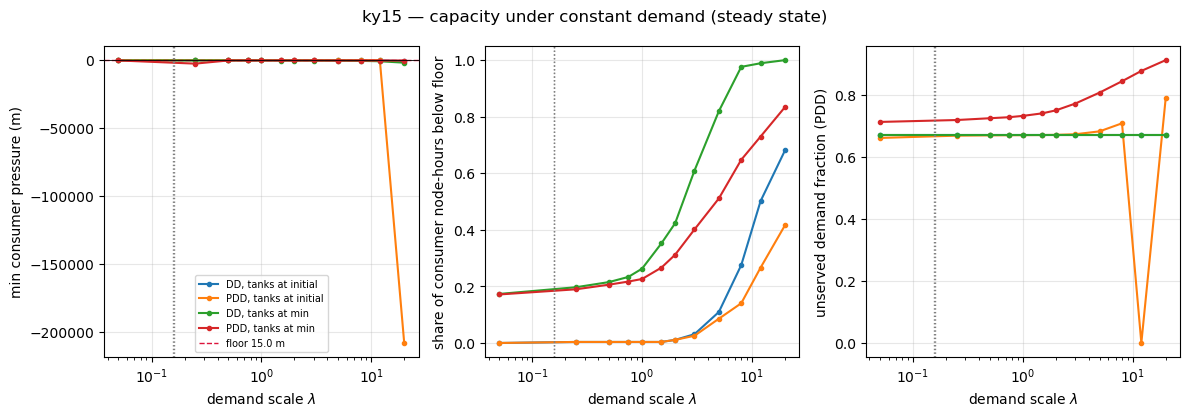

In [14]:
fig = cap.plot_capacity(one)
fig.savefig(OUT_DIR / f"capacity_{FOCUS}.png", dpi=140, bbox_inches="tight")
plt.show()

### 2b. The whole corpus

In [15]:
capres = cap.assess_corpus(files, CFG_CAPACITY)
for name, df in capres.items():
    if isinstance(df, pd.DataFrame) and len(df):
        df.to_csv(OUT_DIR / f"capacity_{name}.csv", index=False)

summ = capres["summary"]
summ.query("tank_level == 'initial' and mode == 'DD'")[
    ["network", "n_consumers", "n_excluded_defects", "base_demand_lps",
     "monotonic", "lambda_star", "max_demand_lps", "max_demand_cmd",
     "binding_kind_top", "status"]].reset_index(drop=True)

  Balerma        3.8s  lambda*=1.0312
  C_Town         0.2s  lambda*=n/a
  D_Town         3.3s  lambda*=0.5547
  Graeme         1.7s  lambda*=0.8281
  ky1            6.4s  lambda*=1.3906
  ky10           8.8s  lambda*=7.1562
  ky11           8.6s  lambda*=7.25
  ky12          16.2s  lambda*=8.5
  ky13           7.3s  lambda*=1.0156
  ky14           4.3s  lambda*=7.4375
  ky15           6.1s  lambda*=0.1562
  ky16           6.9s  lambda*=8.875
  ky17          56.4s  lambda*=1.0469
  ky18          11.0s  lambda*=7.25
  ky19_v        12.5s  lambda*=0.75
  ky2            9.8s  lambda*=7.1562
  ky3            3.9s  lambda*=1.5938
  ky4           11.1s  lambda*=7.3438
  ky5            5.7s  lambda*=2.1875
  ky6            7.2s  lambda*=4.75
  ky7            6.2s  lambda*=1.7812
  ky8           36.6s  lambda*=1.7812
  ky8_v         28.8s  lambda*=1.75
  ky9           19.3s  lambda*=10.25
  NJ1          187.5s  lambda*=20.0
  PA1            4.4s  lambda*=0.3516


,network,n_consumers,n_excluded_defects,base_demand_lps,monotonic,lambda_star,max_demand_lps,max_demand_cmd,binding_kind_top,status
0,Balerma,442.0,0.0,2453.100000,True,1.0312,2529.637,218560.6,friction_limited,bracketed
1,C_Town,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no demand in file
2,D_Town,348.0,0.0,422.267565,True,0.9844,415.680,35914.8,friction_limited,bracketed
3,Graeme,112.0,0.0,5557.030000,True,0.8281,4601.777,397593.5,friction_limited,bracketed
4,ky1,797.0,0.0,86.635458,True,1.3906,120.475,10409.0,friction_limited,bracketed
5,ky10,871.0,0.0,94.722359,True,7.1562,677.852,58566.4,friction_limited,bracketed
6,ky11,694.0,0.0,76.543594,True,7.2500,554.941,47946.9,friction_limited,bracketed
7,ky12,2246.0,0.0,60.044202,True,8.5000,510.376,44096.5,pump_limited,bracketed
8,ky13,718.0,0.0,103.333855,True,1.5469,159.847,13810.8,friction_limited,bracketed
9,ky14,331.0,0.0,45.657681,True,7.4375,339.579,29339.6,friction_limited,bracketed


In [16]:
# Storage-dependence. A NaN at `min` means the network cannot serve even its own
# base demand once its tanks are drawn down -- so its headroom at `initial` is
# borrowed from storage, not supplied by the network.
display(summ.query("mode == 'DD'").pivot_table(
    index="network", columns="tank_level", values="lambda_star", dropna=False))

# DD vs PDD should agree closely on the limit; a wide gap means the cliff and the
# graded measure disagree, which is worth reading before trusting either.
display(summ.query("tank_level == 'initial'").pivot_table(
    index="network", columns="mode", values="lambda_star", dropna=False))

tank_level,initial,min
network,,
Balerma,1.0312,1.0312
C_Town,NaN,NaN
D_Town,0.9844,0.5547
Graeme,0.8281,0.8281
NJ1,20.0000,NaN
PA1,14.0000,0.3516
ky1,1.3906,NaN
ky10,7.1562,NaN
ky11,7.2500,NaN


mode,DD,PDD
network,,
Balerma,1.0312,1.0312
C_Town,NaN,NaN
D_Town,0.9844,NaN
Graeme,0.8281,0.8281
NJ1,20.0000,20.0000
PA1,14.0000,14.0000
ky1,1.3906,1.3906
ky10,7.1562,7.1562
ky11,7.2500,7.2500


In [17]:
# Where does each network bind, and which ones carry a defect load?
if len(capres["binding"]):
    display(capres["binding"].groupby(["network", "binding_kind"]).size()
            .unstack(fill_value=0))
if len(capres["defects"]):
    display(capres["defects"].groupby("network").agg(
        n_defects=("node", "size"),
        worst_pressure_m=("probe_pressure_m", "min"),
        demand_at_risk_lps=("base_demand_lps", "sum"),
        dominant_explanation=("explanation", lambda x: x.value_counts().index[0])))

binding_kind,friction_limited,prv_limited,pump_limited
network,,,
Balerma,25,0,0
D_Town,16,9,0
Graeme,25,0,0
NJ1,25,0,0
PA1,25,0,0
ky1,25,0,0
ky10,9,16,0
ky11,13,12,0
ky12,13,7,5


,n_defects,worst_pressure_m,demand_at_risk_lps,dominant_explanation
network,,,,
PA1,2,9.934854,0.189271,elevation above available gravity head
ky15,17,-85.209961,2.065194,PRV on the supply path caps the head below the...
ky19_v,2,9.118803,0.359614,elevation above available gravity head


In [18]:
# Headroom is what makes drift injection possible: it is the ceiling on how far a
# district's demand can grow before the network, not the scenario, decides the
# outcome. lambda* < 1 means the network is already past its own floor as shipped.
hr = (summ.query("tank_level == 'initial' and mode == 'DD'")
          .set_index("network")[["lambda_star", "base_demand_lps", "max_demand_lps"]]
          .join(cond["tiers"].set_index("network")[["tier", "storage_policy"]])
          .sort_values("lambda_star", ascending=False))
hr["verdict"] = np.select(
    [hr.lambda_star.isna(), hr.lambda_star < 1.0, hr.lambda_star < 2.0],
    ["no capacity established", "OVERLOADED as shipped", "little headroom"],
    default="usable headroom")
hr.to_csv(OUT_DIR / "capacity_headroom.csv")
hr

,lambda_star,base_demand_lps,max_demand_lps,tier,storage_policy,verdict
network,,,,,,
NJ1,20.0000,338.220066,6764.401,T0_as_is,as_is,usable headroom
ky3,15.0000,87.925652,1318.885,T1_conditioned,freeze_tanks,usable headroom
ky4,14.7500,65.651027,968.353,T0_as_is,as_is,usable headroom
PA1,14.0000,192.425099,2693.951,T0_as_is,as_is,usable headroom
ky9,10.2500,58.745182,602.138,T1_conditioned,freeze_tanks,usable headroom
ky7,10.2500,67.000527,686.755,T0_as_is,as_is,usable headroom
ky8,9.7500,107.971300,1052.720,T0_as_is,as_is,usable headroom
ky8_v,9.6250,107.718309,1036.789,T0_as_is,as_is,usable headroom
ky6,8.8750,71.802953,637.251,T0_as_is,as_is,usable headroom


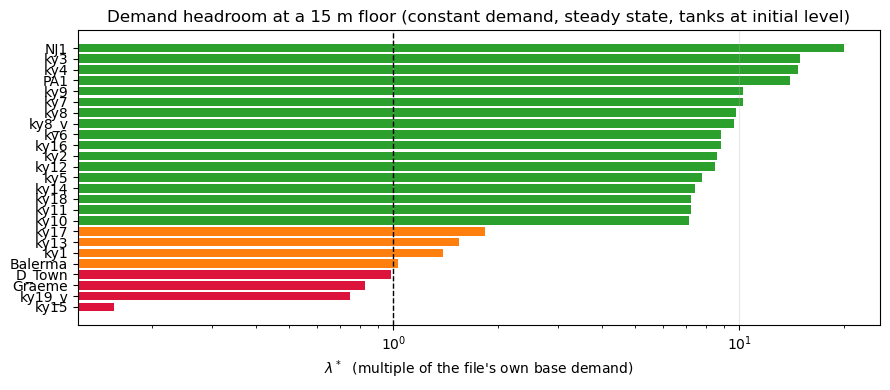

In [19]:
fig, ax = plt.subplots(figsize=(9, 4))
d = hr.dropna(subset=["lambda_star"]).sort_values("lambda_star")
colors = ["crimson" if v < 1 else "tab:orange" if v < 2 else "tab:green"
          for v in d.lambda_star]
ax.barh(d.index, d.lambda_star, color=colors)
ax.axvline(1.0, color="k", ls="--", lw=1)
ax.set_xscale("log")
ax.set_xlabel("$\\lambda^*$  (multiple of the file's own base demand)")
ax.set_title(f"Demand headroom at a {PRESSURE_FLOOR_M:.0f} m floor "
             "(constant demand, steady state, tanks at initial level)")
ax.grid(axis="x", alpha=0.3)
fig.tight_layout()
fig.savefig(OUT_DIR / "capacity_headroom.png", dpi=140, bbox_inches="tight")
plt.show()